# 0.0 Setup

In [1]:
import os
import gc
import json
from pathlib import Path

import re
import pickle
import importlib
import numpy as np
import pandas as pd
import openpyxl as opxl
import matplotlib.pyplot as plt
from typing import Optional, Dict, Any, List

import geopandas as gpd
from difflib import SequenceMatcher
from sklearn.impute import SimpleImputer, KNNImputer

# None means 'no limit'
pd.set_option('display.max_columns', None)

PROJECT_DIR = Path.cwd().parent
if 'modules' not in os.listdir(Path.cwd()):
    os.chdir(PROJECT_DIR)

DATA_DIR = 'data'
DATA_PUBLIC_DIR = 'data/public'
DATA_PRIVATE_DIR = 'data/private'
DATA_PROCESSED_DIR = 'data/processed'
OUTPUT_DIR = 'output'

# 1.0. Load data

In [2]:
# Load school information table for joining geographic information of schools
fpath = 'output/processed_project_bukas_school_information.parquet'
sch_info = pd.read_parquet(fpath)
print(sch_info.shape)

(61442, 20)


In [3]:
display(sch_info.head(2))

,school_id,school_name,region,division,province,school_district,legislative_district,municipality,barangay,street_address,sector,school_management,annex_status,offers_es,offers_jhs,offers_shs,in_enr_2022_23,in_enr_2023_24,in_enr_2024_25,old_region
0,100001,Apaleng-Libtong ES,Region I,Ilocos Norte,ILOCOS NORTE,Bacarra I,1st District,BACARRA,LIBTONG,"Brgy. 21, Libtong, Bacarra, Ilocos Norte",Public,DepEd,Standalone School,True,False,False,True,True,True,Region I
1,100002,Bacarra CES,Region I,Ilocos Norte,ILOCOS NORTE,Bacarra I,1st District,BACARRA,SANTA RITA (POB.),Santa Rita,Public,DepEd,Standalone School,True,False,False,True,True,True,Region I


## 1.1. Coordinates data

In [4]:
%%time
fname = 'processed_public_school_coordinates.parquet'
outpath = os.path.join(OUTPUT_DIR, fname)
df_pub = pd.read_parquet(outpath)

# Join school information
df_pub = df_pub.merge(
    sch_info[['school_id','old_region','province']],
    on='school_id',
    how='left'
)
print(df_pub.shape)

(47821, 7)
CPU times: user 19.3 ms, sys: 18.6 ms, total: 37.9 ms
Wall time: 46.8 ms


In [5]:
%%time
fname = 'processed_private_school_coordinates.parquet'
outpath = os.path.join(OUTPUT_DIR, fname)
df_priv = pd.read_parquet(outpath)

# Join school information
df_priv = df_priv.merge(
    sch_info[['school_id','old_region','province']],
    on='school_id',
    how='left'
)
print(df_priv.shape)

(11831, 6)
CPU times: user 15.2 ms, sys: 7.75 ms, total: 23 ms
Wall time: 25.4 ms


### Inspect

In [6]:
display(df_pub)

,school_id,longitude,latitude,coord_valid,coord_missing,old_region,province
0,100001,120.614372,18.266860,True,False,Region I,ILOCOS NORTE
1,100002,120.609487,18.251272,True,False,Region I,ILOCOS NORTE
2,100003,120.616050,18.234670,True,False,Region I,ILOCOS NORTE
3,100004,120.587415,18.250121,True,False,Region I,ILOCOS NORTE
4,100005,120.641002,18.294093,True,False,Region I,ILOCOS NORTE
...,...,...,...,...,...,...,...
47816,320702,121.053254,14.457782,True,False,NCR,NCR FOURTH DISTRICT
47817,131785,125.886580,8.558120,True,False,CARAGA,AGUSAN DEL SUR
47818,137272,121.260711,14.611189,True,False,Region IV-A,RIZAL
47819,306294,123.152462,7.515867,True,False,Region IX,ZAMBOANGA DEL SUR


In [7]:
display(df_priv)

,school_id,longitude,latitude,coord_valid,old_region,province
0,400860,120.6149,17.58521,True,CAR,ABRA
1,406102,120.6145,17.59657,True,CAR,ABRA
2,406104,120.61364,17.59447,True,CAR,ABRA
3,406107,120.617597,17.596118,True,CAR,ABRA
4,406108,120.614023,17.596496,True,CAR,ABRA
...,...,...,...,...,...,...
11826,407378,122.86493,7.35855,True,Region IX,ZAMBOANGA SIBUGAY
11827,410936,122.5626,7.87866,True,Region IX,ZAMBOANGA SIBUGAY
11828,456516,122.5626,7.87866,True,Region IX,ZAMBOANGA SIBUGAY
11829,456520,122.5626,7.87866,True,Region IX,ZAMBOANGA SIBUGAY


## 1.2. Road networks

In [8]:
dir_networks = 'output/province_road_networks'
network_fnames = os.listdir(dir_networks)
print(network_fnames)

['PH01028_ilocos-norte.geojsonl', 'PH01029_ilocos-sur.geojsonl', 'PH01033_la-union.geojsonl', 'PH01055_pangasinan.geojsonl', 'PH02009_batanes.geojsonl', 'PH02015_cagayan.geojsonl', 'PH02031_isabela.geojsonl', 'PH02050_nueva-vizcaya.geojsonl', 'PH02057_quirino.geojsonl', 'PH03008_bataan.geojsonl', 'PH03014_bulacan.geojsonl', 'PH03049_nueva-ecija.geojsonl', 'PH03054_pampanga.geojsonl', 'PH03069_tarlac.geojsonl', 'PH03071_zambales.geojsonl', 'PH03077_aurora.geojsonl', 'PH04010_batangas.geojsonl', 'PH04021_cavite.geojsonl', 'PH04034_laguna.geojsonl', 'PH04056_quezon.geojsonl', 'PH04058_rizal.geojsonl', 'PH05005_albay.geojsonl', 'PH05016_camarines-norte.geojsonl', 'PH05017_camarines-sur.geojsonl', 'PH05020_catanduanes.geojsonl', 'PH05041_masbate.geojsonl', 'PH05062_sorsogon.geojsonl', 'PH06004_aklan.geojsonl', 'PH06006_antique.geojsonl', 'PH06019_capiz.geojsonl', 'PH06030_iloilo.geojsonl', 'PH06045_negros-occidental.geojsonl', 'PH06079_guimaras.geojsonl', 'PH07012_bohol.geojsonl', 'PH07022_

### Inpect NCR

In [9]:
ncr_fpaths = [os.path.join(dir_networks, fname) for fname in network_fnames if re.search(r'-ncr', fname)]
print(ncr_fpaths)

['output/province_road_networks/PH13039_national-capital-region-ncr.geojsonl', 'output/province_road_networks/PH13074_national-capital-region-ncr.geojsonl', 'output/province_road_networks/PH13075_national-capital-region-ncr.geojsonl', 'output/province_road_networks/PH13076_national-capital-region-ncr.geojsonl']


In [10]:
gdfs = []
for fpath in ncr_fpaths:
    gdf = gpd.read_file(fpath, engine="pyogrio")
    gdfs.append(gdf)

print(len(gdfs))

4


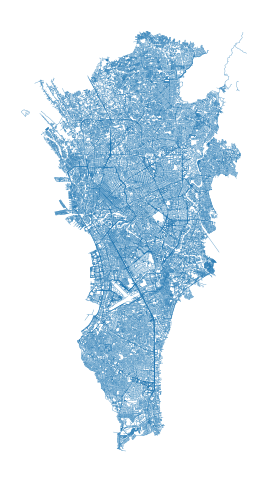

In [11]:
fig, ax = plt.subplots(figsize=(6,6))

for gdf in gdfs:
    gdf.plot(figsize=(8,8), linewidth=0.2, ax=ax)

ax.set_aspect("equal")
ax.axis("off")

plt.show()
plt.close()

### Inspect Region IV-A

In [12]:
r4a_fpaths = [os.path.join(dir_networks, fname) for fname in network_fnames if re.search(r'^PH040', fname)]
display(r4a_fpaths)

['output/province_road_networks/PH04010_batangas.geojsonl',
 'output/province_road_networks/PH04021_cavite.geojsonl',
 'output/province_road_networks/PH04034_laguna.geojsonl',
 'output/province_road_networks/PH04056_quezon.geojsonl',
 'output/province_road_networks/PH04058_rizal.geojsonl']

In [13]:
gdfs = []
for fpath in r4a_fpaths:
    gdf = gpd.read_file(fpath, engine="pyogrio")
    gdfs.append(gdf)

print(len(gdfs))

5


In [14]:
display(gdfs[0])

,osm_id,highway,name,oneway,maxspeed,geometry
0,4691441,tertiary,Laurena Street,None,None,"LINESTRING (121.15119 14.08824, 121.15101 14.0..."
1,4691442,primary,National Highway 4,yes,None,"LINESTRING (121.07039 13.79443, 121.07044 13.7..."
2,4691444,primary,Tanauan-Talisay-Tagaytay Road,None,None,"LINESTRING (121.13281 14.08625, 121.13221 14.0..."
3,4691445,primary,Tanauan-Talisay-Tagaytay Road,None,None,"LINESTRING (121.14019 14.08467, 121.13949 14.0..."
4,4691446,motorway_link,None,yes,40,"LINESTRING (121.13865 14.12651, 121.13908 14.1..."
...,...,...,...,...,...,...
49507,1433941308,unclassified,None,None,None,"LINESTRING (121.14998 14.02387, 121.152 14.02493)"
49508,1433941309,service,None,None,None,"LINESTRING (121.15258 14.02393, 121.15272 14.0..."
49509,1433941310,unclassified,None,yes,None,"LINESTRING (121.15323 14.02009, 121.15295 14.0..."
49510,1433941311,unclassified,None,yes,None,"LINESTRING (121.15257 14.02111, 121.15287 14.0..."


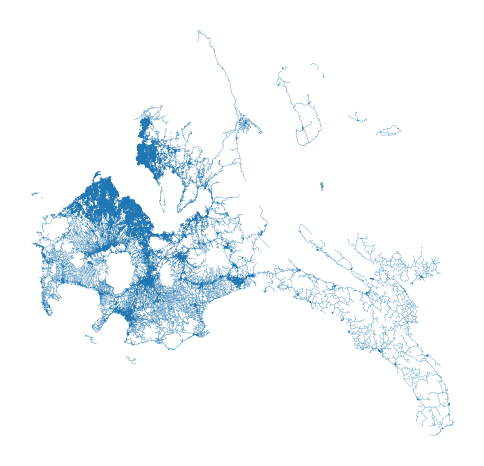

In [15]:
fig, ax = plt.subplots(figsize=(6,6))

for gdf in gdfs:
    gdf.plot(figsize=(8,8), linewidth=0.2, ax=ax)

ax.set_aspect("equal")
ax.axis("off")

plt.show()
plt.close()

### NCR + R4A

In [16]:
# paths = ncr_fpaths + r4a_fpaths

# gdfs_all = []
# for fpath in paths:
#     gdf = gpd.read_file(fpath, engine="pyogrio")
#     gdfs_all.append(gdf)

# print(len(gdfs_all))

In [17]:
# fig, ax = plt.subplots(figsize=(6,6))

# for gdf in gdfs_all:
#     gdf.plot(figsize=(8,8), linewidth=0.2, ax=ax)

# ax.set_aspect("equal")
# ax.axis("off")

# plt.show()
# plt.close()

# 2.0. Graph Network

## 2.1. Build
Section 1.0 contains the datasets we need to build a graph network of public and private schools. The nodes of this graph network will be our schools whose position are directly derived from their respective longitude and latitude. The edges will be a school's distance in meters from many schools via the road networks.

For now, we will contain our graph newtork to only contain public and private schools from the National Capital Region and Region IV-A (or CALABARZON).

In [18]:
# =============================================================================                                                                    
# 2.1. Load Road Networks and Build NetworkX Graph                                                                                                 
# =============================================================================                                                                    
import networkx as nx
from scipy import sparse
from scipy.spatial import cKDTree
from scipy.sparse import lil_matrix
from scipy.sparse.csgraph import dijkstra
from pyproj import Transformer

In [19]:
# Define the provinces to include (NCR + Region IV-A)                                                                                              
target_fpaths = ncr_fpaths + r4a_fpaths                                                                                                            
print(f"Loading {len(target_fpaths)} road network files...")                                                                                       
                                                                                                                                                 
# Load all road segments into a single GeoDataFrame                                                                                                
road_gdfs = []                                                                                                                                     
for fpath in target_fpaths:                                                                                                                        
  gdf = gpd.read_file(fpath, engine="pyogrio")                                                                                                   
  road_gdfs.append(gdf)                                                                                                                          
                                                                                                                                                 
roads_gdf = pd.concat(road_gdfs, ignore_index=True)                                                                                                
print(f"Total road segments: {len(roads_gdf):,}")

Loading 9 road network files...
Total road segments: 371,831


In [20]:
print(roads_gdf.shape)
display(roads_gdf.head())

(371831, 6)


,osm_id,highway,name,oneway,maxspeed,geometry
0,2667099,primary,Lerma Street,yes,60,"LINESTRING (120.98539 14.6046, 120.98545 14.60..."
1,2667111,primary,Quezon Boulevard,yes,60,"LINESTRING (120.98018 14.59292, 120.98002 14.5..."
2,2667112,secondary,F. B. Harrison Street,None,40,"LINESTRING (120.98944 14.56019, 120.98949 14.5..."
3,4075788,tertiary,25th Street,yes,None,"LINESTRING (120.97132 14.58278, 120.97237 14.5..."
4,4075790,trunk,Bonifacio Drive,yes,60,"LINESTRING (120.97268 14.58777, 120.97289 14.5..."


### Save road network

In [21]:
type(roads_gdf)

geopandas.geodataframe.GeoDataFrame

In [22]:
# fname = 'road_network_ncr_region4a.geojson'
# fpath = os.path.join(OUTPUT_DIR, fname)

# # Save as GeoJSON
# roads_gdf.to_file(fpath, driver="GeoJSON")

## 2.2.

### old_a

In [23]:
# # =============================================================================                                                                    
# # 2.2. Convert GeoDataFrame to NetworkX Graph                                                                                                      
# # =============================================================================                                                                    
                                                                                                                                                 
# def build_road_graph(gdf: gpd.GeoDataFrame) -> nx.MultiDiGraph:                                                                                    
#   """                                                                                                                                            
#   Convert road segments GeoDataFrame to NetworkX graph.                                                                                          
                                                                                                                                                 
#   Nodes: Coordinate tuples (lon, lat) rounded to 5 decimals                                                                                      
#   Edges: Road segments with length in meters (approximate)                                                                                       
#   """                                                                                                                                            
#   G = nx.MultiDiGraph()                                                                                                                          
                                                                                                                                                 
#   for idx, row in gdf.iterrows():                                                                                                                
#       geom = row.geometry                                                                                                                        
#       if geom.geom_type != 'LineString':                                                                                                         
#           continue                                                                                                                               
                                                                                                                                                 
#       coords = list(geom.coords)                                                                                                                 
                                                                                                                                                 
#       # Add edges between consecutive coordinates                                                                                                
#       for i in range(len(coords) - 1):                                                                                                           
#           # Round coordinates to 5 decimals (~1 meter precision)                                                                                 
#           start = tuple(np.round(coords[i], 5))                                                                                                  
#           end = tuple(np.round(coords[i + 1], 5))                                                                                                
                                                                                                                                                 
#           # Approximate length in meters (degrees to meters at ~14°N latitude)                                                                   
#           # 1 degree longitude ≈ 109,000 m, 1 degree latitude ≈ 111,320 m                                                                        
#           dx = (coords[i + 1][0] - coords[i][0]) * 109000                                                                                        
#           dy = (coords[i + 1][1] - coords[i][1]) * 111320                                                                                        
#           length = np.sqrt(dx**2 + dy**2)                                                                                                        
                                                                                                                                                 
#           G.add_edge(                                                                                                                            
#               start, end,                                                                                                                        
#               length=length,                                                                                                                     
#               highway=row.get('highway', 'unknown'),                                                                                             
#               oneway=row.get('oneway', None)                                                                                                     
#           )                                                                                                                                      
                                                                                                                                                 
#   # Add node attributes (x, y coordinates)                                                                                                       
#   for node in G.nodes():                                                                                                                         
#       G.nodes[node]['x'] = node[0]  # longitude                                                                                                  
#       G.nodes[node]['y'] = node[1]  # latitude                                                                                                   
                                                                                                                                                 
#   return G

In [24]:
# # Build the graph                                                                                                                                  
# print("Building NetworkX graph from road segments...")                                                                                             
# G_road = build_road_graph(roads_gdf)                                                                                                               
                                                                                                                                                 
# print(f"Road network graph:")                                                                                                                      
# print(f"  Nodes: {G_road.number_of_nodes():,}")                                                                                                    
# print(f"  Edges: {G_road.number_of_edges():,}")

### new_a

In [25]:
def build_road_graph(gdf: gpd.GeoDataFrame) -> nx.MultiDiGraph:                                                                                                                    
  """                                                                                                                                                                            
  Convert road segments GeoDataFrame to NetworkX graph.                                                                                                                          
                                                                                                                                                                                 
  Nodes: Coordinate tuples (lon, lat) rounded to 5 decimals                                                                                                                      
  Edges: Road segments with length in meters (approximate)                                                                                                                       
                                                                                                                                                                                 
  FIX: Now adds reverse edges for non-oneway roads to enable                                                                                                                     
  bidirectional routing (matches real-world road traversal).                                                                                                                     
  """                                                                                                                                                                            
  G = nx.MultiDiGraph()                                                                                                                                                          
                                                                                                                                                                                 
  edges_added = 0                                                                                                                                                                
  reverse_edges_added = 0                                                                                                                                                        
                                                                                                                                                                                 
  for idx, row in gdf.iterrows():                                                                                                                                                
      geom = row.geometry                                                                                                                                                        
      if geom.geom_type != 'LineString':                                                                                                                                         
          continue                                                                                                                                                               
                                                                                                                                                                                 
      coords = list(geom.coords)                                                                                                                                                 
      oneway = row.get('oneway', None)                                                                                                                                           
      highway = row.get('highway', 'unknown')                                                                                                                                    
                                                                                                                                                                                 
      # Add edges between consecutive coordinates                                                                                                                                
      for i in range(len(coords) - 1):                                                                                                                                           
          # Round coordinates to 5 decimals (~1 meter precision)                                                                                                                 
          start = tuple(np.round(coords[i], 5))                                                                                                                                  
          end = tuple(np.round(coords[i + 1], 5))                                                                                                                                
                                                                                                                                                                                 
          # Approximate length in meters (degrees to meters at ~14°N latitude)                                                                                                   
          # 1 degree longitude ≈ 109,000 m, 1 degree latitude ≈ 111,320 m                                                                                                        
          dx = (coords[i + 1][0] - coords[i][0]) * 109000                                                                                                                        
          dy = (coords[i + 1][1] - coords[i][1]) * 111320                                                                                                                        
          length = np.sqrt(dx**2 + dy**2)                                                                                                                                        
                                                                                                                                                                                 
          # Always add forward edge (digitization direction)                                                                                                                     
          G.add_edge(start, end, length=length, highway=highway, oneway=oneway)                                                                                                  
          edges_added += 1                                                                                                                                                       
                                                                                                                                                                                 
          # Add reverse edge if NOT a one-way road                                                                                                                               
          # oneway='yes' means one-way in digitization direction                                                                                                                 
          # oneway='-1' means one-way in reverse direction (rare)                                                                                                                
          # oneway=None or other values means bidirectional                                                                                                                      
          if oneway != 'yes':                                                                                                                                                    
              G.add_edge(end, start, length=length, highway=highway, oneway=oneway)                                                                                              
              reverse_edges_added += 1                                                                                                                                           
                                                                                                                                                                                 
  # Add node attributes (x, y coordinates)                                                                                                                                       
  for node in G.nodes():                                                                                                                                                         
      G.nodes[node]['x'] = node[0]  # longitude                                                                                                                                  
      G.nodes[node]['y'] = node[1]  # latitude                                                                                                                                   
                                                                                                                                                                                 
  print(f"  Forward edges added: {edges_added:,}")                                                                                                                               
  print(f"  Reverse edges added: {reverse_edges_added:,}")                                                                                                                       
  print(f"  Total edges: {G.number_of_edges():,}")                                                                                                                               
                                                                                                                                                                                 
  return G

In [26]:
# Build the graph                                                                                                                                                                  
print("Building NetworkX graph from road segments...")                                                                                                                             
G_road = build_road_graph(roads_gdf)                                                                                                                                               
                                                                                                                                                                                 
print(f"\nRoad network graph:")                                                                                                                                                    
print(f"  Nodes: {G_road.number_of_nodes():,}")                                                                                                                                    
print(f"  Edges: {G_road.number_of_edges():,}")

Building NetworkX graph from road segments...
  Forward edges added: 1,915,602
  Reverse edges added: 1,727,078
  Total edges: 3,642,680

Road network graph:
  Nodes: 1,758,987
  Edges: 3,642,680


## 2.3.

In [27]:
# =============================================================================                                                                    
# 2.3. Project Graph to EPSG:3123 (PRS92 Philippines)                                                                                              
# =============================================================================                                                                    
                                                                                                                                                 
def project_graph_to_3123(G: nx.MultiDiGraph) -> nx.MultiDiGraph:                                                                                  
  """                                                                                                                                            
  Project graph coordinates from EPSG:4326 to EPSG:3123.                                                                                         
  Recomputes edge lengths in meters using projected coordinates.                                                                                 
  """                                                                                                                                            
  transformer = Transformer.from_crs('EPSG:4326', 'EPSG:3123', always_xy=True)                                                                   
                                                                                                                                                 
  G_proj = nx.MultiDiGraph()                                                                                                                     
  node_mapping = {}  # old_node -> new_node                                                                                                      
                                                                                                                                                 
  # Project nodes                                                                                                                                
  print("  Projecting nodes...")                                                                                                                 
  for node in G.nodes():                                                                                                                         
      x_4326, y_4326 = node                                                                                                                      
      x_3123, y_3123 = transformer.transform(x_4326, y_4326)                                                                                     
      new_node = (round(x_3123, 2), round(y_3123, 2))                                                                                            
      node_mapping[node] = new_node                                                                                                              
                                                                                                                                                 
      G_proj.add_node(new_node, x=x_3123, y=y_3123)                                                                                              
                                                                                                                                                 
  # Project edges and recompute lengths in meters                                                                                                
  print("  Projecting edges and recomputing lengths...")                                                                                         
  for u, v, key, data in G.edges(keys=True, data=True):                                                                                          
      u_proj = node_mapping[u]                                                                                                                   
      v_proj = node_mapping[v]                                                                                                                   
                                                                                                                                                 
      # Compute accurate length in meters (projected coordinates)                                                                                
      length = np.sqrt((u_proj[0] - v_proj[0])**2 + (u_proj[1] - v_proj[1])**2)                                                                  
                                                                                                                                                 
      G_proj.add_edge(                                                                                                                           
          u_proj, v_proj, key=key,                                                                                                               
          length=length,                                                                                                                         
          highway=data.get('highway', 'unknown'),                                                                                                
          oneway=data.get('oneway', None)                                                                                                        
      )                                                                                                                                          
                                                                                                                                                 
  return G_proj, node_mapping                                                                                                                    
                                                                                                                                                 
# Project the graph                                                                                                                                
print("Projecting graph to EPSG:3123...")                                                                                                          
G_road_proj, node_mapping_4326_to_3123 = project_graph_to_3123(G_road)                                                                             
                                                                                                                                                 
print(f"Projected graph:")                                                                                                                         
print(f"  Nodes: {G_road_proj.number_of_nodes():,}")                                                                                               
print(f"  Edges: {G_road_proj.number_of_edges():,}")

Projecting graph to EPSG:3123...
  Projecting nodes...
  Projecting edges and recomputing lengths...
Projected graph:
  Nodes: 1,758,987
  Edges: 3,642,680


## 2.4.

In [28]:
display(df_pub.head(1))
display(df_priv.head(1))

,school_id,longitude,latitude,coord_valid,coord_missing,old_region,province
0,100001,120.614372,18.26686,True,False,Region I,ILOCOS NORTE


,school_id,longitude,latitude,coord_valid,old_region,province
0,400860,120.6149,17.58521,True,CAR,ABRA


In [29]:
# =============================================================================                                                                                    
# 2.4. Prepare School Data                                                                                                                                         
# =============================================================================                                                                                    
                                                                                                                                                                 
# Define target regions                                                                                                                                            
target_regions = ['NCR', 'Region IV-A']                                                                                                                            
print(f"Target regions are: {', '.join(target_regions)}\n")

# Filter public schools to target regions                                                                                                                          
mask = (
    (df_pub['old_region'].isin(target_regions))
    & (df_pub['coord_valid'] == True)
)
df_pub_filtered = df_pub[mask].copy()                                                                                         
df_pub_filtered['sector'] = 'public'                                                                                                                               
                                                                                                                                                                 
# Filter private schools to target regions                                                                                                                         
mask = (
    (df_priv['old_region'].isin(target_regions))
    & (df_priv['coord_valid'] == True)
)
df_priv_filtered = df_priv[mask].copy()                                                                                      
df_priv_filtered['sector'] = 'private'                                                                                                                             

# To account for public &  private schools not included due to invalid coordinates
mask = df_pub['old_region'].isin(target_regions)
df_pub_in_regions = df_pub[mask]
invalid_pubs_in_regions = df_pub_in_regions[df_pub_in_regions['coord_valid'] == False]

mask = df_priv['old_region'].isin(target_regions)
df_priv_in_regions = df_priv[mask]
invalid_privs_in_regions = df_priv_in_regions[df_priv_in_regions['coord_valid'] == False]

print(f"Public schools in target regions: {len(df_pub_filtered):,}")                                                                                               
print(f"Valid Private schools in target regions: {len(df_priv_filtered):,}")                                                                                             
                                                                                                                                                                 
# Combine public and private schools with essential columns only                                                                                                   
essential_cols = ['school_id', 'longitude', 'latitude', 'sector']                                                                                                  
                                                                                                                                                                 
schools_df = pd.concat([                                                                                                                                           
  df_pub_filtered[essential_cols],                                                                                                                               
  df_priv_filtered[essential_cols]                                                                                                                               
], ignore_index=True)                                                                                                                                              
                                                                                                                                                                 
# Ensure school_id is string                                                                                                                                       
schools_df['school_id'] = schools_df['school_id'].astype(str)                                                                                                      
                                                                                                                                                                 
# Drop any rows with missing coordinates                                                                                                                           
schools_df = schools_df.dropna(subset=['longitude', 'latitude'])                                                                                                   
                                                                                                                                                                 
print(f"\nCombined schools DataFrame:")                                                                                                                            
print(f"  Total schools: {len(schools_df):,}")                                                                                                                     
print(f"  Columns: {list(schools_df.columns)}")                                                                                                                    
display(schools_df.head())

# Notes on invalidated schools
pct_inv_pub = np.round((len(invalid_pubs_in_regions) / len(df_pub_in_regions)) * 100, 2)
pct_inv_priv = np.round((len(invalid_privs_in_regions) / len(df_priv_in_regions)) * 100, 2)
print(f"Count of PUBLIC schools with invalid coordinates {len(invalid_pubs_in_regions):,} ({pct_inv_pub:.2f}%) of {len(df_pub_in_regions):,}")
print(f"Count of PRIVATE schools with invalid coordinates {len(invalid_privs_in_regions):,} ({pct_inv_priv:.2f}%) of {len(df_priv_in_regions):,}")

Target regions are: NCR, Region IV-A

Public schools in target regions: 4,367
Valid Private schools in target regions: 3,964

Combined schools DataFrame:
  Total schools: 8,331
  Columns: ['school_id', 'longitude', 'latitude', 'sector']


,school_id,longitude,latitude,sector
0,107900,120.960226,14.28325,public
1,107901,120.935551,14.326691,public
2,107902,120.93479,14.32639,public
3,107903,120.943507,14.264903,public
4,107904,120.94771,14.27544,public


Count of PUBLIC schools with invalid coordinates 27 (0.61%) of 4,394
Count of PRIVATE schools with invalid coordinates 320 (7.47%) of 4,284


### Save school coordinates

In [30]:
for col in ['longitude','latitude']:
    schools_df[col] = schools_df[col].astype(float)

for col in ['school_id','sector']:
    schools_df[col] = schools_df[col].astype(str)

fpath = 'output/all_schools_coordinates_ncr_region4a.parquet'
schools_df.to_parquet(fpath)

## 2.5.

In [31]:
# =============================================================================                                                                                    
# 2.5. Snap Schools to Road Network Nodes                                                                                                                          
# =============================================================================                                                                                    
                                                                                                                                                                 
# Create transformer for school coordinates                                                                                                                        
transformer = Transformer.from_crs('EPSG:4326', 'EPSG:3123', always_xy=True)                                                                                       
                                                                                                                                                                 
# Project school coordinates to EPSG:3123                                                                                                                          
print("Projecting school coordinates to EPSG:3123...")                                                                                                             
school_coords_3123 = []                                                                                                                                            
for idx, row in schools_df.iterrows():                                                                                                                             
  x_3123, y_3123 = transformer.transform(row['longitude'], row['latitude'])                                                                                      
  school_coords_3123.append((x_3123, y_3123))                                                                                                                    
                                                                                                                                                                 
school_coords_3123 = np.array(school_coords_3123)                                                                                                                  
print(f"  Projected {len(school_coords_3123):,} school coordinates")                                                                                               
                                                                                                                                                                 
# Extract road network node coordinates                                                                                                                            
print("\nBuilding KDTree from road network nodes...")                                                                                                              
node_list = list(G_road_proj.nodes())                                                                                                                              
node_coords = np.array([[G_road_proj.nodes[n]['x'], G_road_proj.nodes[n]['y']]                                                                                     
                      for n in node_list])                                                                                                                       
                                                                                                                                                                 
# Build KDTree for fast nearest neighbor search                                                                                                                    
tree = cKDTree(node_coords)                                                                                                                                        
print(f"  KDTree built with {len(node_list):,} nodes")                                                                                                             
                                                                                                                                                                 
# Find nearest road node for each school                                                                                                                           
print("\nSnapping schools to nearest road nodes...")                                                                                                               
distances, indices = tree.query(school_coords_3123)                                                                                                                
                                                                                                                                                                 
# Create mapping dictionaries                                                                                                                                      
school_to_node = {}  # school_id -> road_node                                                                                                                      
node_to_schools = {}  # road_node -> [school_ids]                                                                                                                  
                                                                                                                                                                 
snap_distances = []                                                                                                                                                
for i, (idx, row) in enumerate(schools_df.iterrows()):                                                                                                             
  school_id = row['school_id']                                                                                                                                   
  nearest_node = node_list[indices[i]]                                                                                                                           
  snap_dist = distances[i]                                                                                                                                       
                                                                                                                                                                 
  school_to_node[school_id] = nearest_node                                                                                                                       
                                                                                                                                                                 
  if nearest_node not in node_to_schools:                                                                                                                        
      node_to_schools[nearest_node] = []                                                                                                                         
  node_to_schools[nearest_node].append(school_id)                                                                                                                
                                                                                                                                                                 
  snap_distances.append(snap_dist)                                                                                                                               
                                                                                                                                                                 
snap_distances = np.array(snap_distances)                                                                                                                          
                                                                                                                                                                 
# Report statistics                                                                                                                                                
print(f"\nSnapping statistics:")                                                                                                                                   
print(f"  Schools snapped: {len(school_to_node):,}")                                                                                                               
print(f"  Unique road nodes used: {len(node_to_schools):,}")                                                                                                       
print(f"  Snap distance (meters):")                                                                                                                                
print(f"    Min: {snap_distances.min():.1f}")                                                                                                                      
print(f"    Max: {snap_distances.max():.1f}")                                                                                                                      
print(f"    Mean: {snap_distances.mean():.1f}")                                                                                                                    
print(f"    Median: {np.median(snap_distances):.1f}")                                                                                                              
print(f"  Schools >500m from road: {(snap_distances > 500).sum():,}")

Projecting school coordinates to EPSG:3123...
  Projected 8,331 school coordinates

Building KDTree from road network nodes...
  KDTree built with 1,758,987 nodes

Snapping schools to nearest road nodes...

Snapping statistics:
  Schools snapped: 8,307
  Unique road nodes used: 8,108
  Snap distance (meters):
    Min: 0.0
    Max: 476486.4
    Mean: 624.0
    Median: 25.9
  Schools >500m from road: 163


## 2.6.

In [32]:
%%time
# =============================================================================                                                                                    
# 2.6. Convert NetworkX Graph to Scipy Sparse Matrix                                                                                                               
# =============================================================================                                                                                    
                                                                                                                                                                 
print("Converting NetworkX graph to scipy sparse matrix...")                                                                                                       
                                                                                                                                                                 
# Create node index mappings                                                                                                                                       
node_index_map = {node: idx for idx, node in enumerate(G_road_proj.nodes())}                                                                                       
index_node_map = {idx: node for node, idx in node_index_map.items()}                                                                                               
                                                                                                                                                                 
n_nodes = len(node_index_map)                                                                                                                                      
print(f"  Total nodes: {n_nodes:,}")                                                                                                                               
                                                                                                                                                                 
# Build sparse matrix in LIL format (efficient for construction)                                                                                                   
print("  Building LIL sparse matrix...")                                                                                                                           
adj_matrix = lil_matrix((n_nodes, n_nodes), dtype=np.float32)                                                                                                      
                                                                                                                                                                 
for u, v, data in G_road_proj.edges(data=True):                                                                                                                    
  u_idx = node_index_map[u]                                                                                                                                      
  v_idx = node_index_map[v]                                                                                                                                      
  length = data.get('length', 1.0)                                                                                                                               
  adj_matrix[u_idx, v_idx] = length                                                                                                                              
                                                                                                                                                                 
# Convert to CSR format (efficient for computation)                                                                                                                
print("  Converting to CSR format...")                                                                                                                             
adj_matrix_csr = adj_matrix.tocsr()                                                                                                                                
                                                                                                                                                                 
print(f"\nSparse matrix created:")                                                                                                                                 
print(f"  Shape: {adj_matrix_csr.shape}")                                                                                                                          
print(f"  Non-zero entries: {adj_matrix_csr.nnz:,}")                                                                                                               
print(f"  Density: {adj_matrix_csr.nnz / (n_nodes * n_nodes) * 100:.6f}%")

Converting NetworkX graph to scipy sparse matrix...
  Total nodes: 1,758,987
  Building LIL sparse matrix...
  Converting to CSR format...

Sparse matrix created:
  Shape: (1758987, 1758987)
  Non-zero entries: 3,613,561
  Density: 0.000117%
CPU times: user 7.71 s, sys: 652 ms, total: 8.37 s
Wall time: 8.4 s


## 2.7.

In [33]:
# Save the sparse adjacency matrix                                                                        
                                                                                 
# sparse.save_npz('output/scratch/adj_matrix_csr.npz', adj_matrix_csr)                                  
# print("Saved: adj_matrix_csr.npz")                                                                        
                                                                                                        
# # Save school_to_node mapping                                                                             
# with open('output/scratch/school_to_node.pkl', 'wb') as f:                                            
#   pickle.dump(school_to_node, f)                                                                        
# print("Saved: school_to_node.pkl")                                                                                                    

In [34]:
# Delete large objects we no longer need                                                                  
objects_to_delete = ['adj_matrix_csr','school_to_node']                                     
                                                                                                        
for obj_name in objects_to_delete:                                                                        
  if obj_name in dir():                                                                                 
      exec(f'del {obj_name}')                                                                           
      print(f"Deleted: {obj_name}")                                                                     
                                                                                                        
# Force garbage collection                                                                                
gc.collect()                                                                                              
                                                                                                        
print(f"\nMemory cleanup complete") 

Deleted: adj_matrix_csr
Deleted: school_to_node

Memory cleanup complete


In [ ]:
# Save node list (for index mapping)                                                                      
with open('output/scratch/node_list.pkl', 'wb') as f:                                                 
  pickle.dump(list(G_road_proj.nodes()), f)                                                             
print("Saved: node_list.pkl")                                                                             
                                                                                                        
# Save node coordinates                                                                                   
node_coords_dict = {n: (G_road_proj.nodes[n]['x'], G_road_proj.nodes[n]['y'])                             
                  for n in G_road_proj.nodes()}                                                         
with open('output/scratch/node_coords.pkl', 'wb') as f:                                               
  pickle.dump(node_coords_dict, f)                                                                      
print("Saved: node_coords.pkl")                                                                           
                                                                                                        
print("\nAll intermediate data saved. Safe to restart kernel.")

### old_a

In [33]:
# # Clear old checkpoints                                                                                                                                                            
# CHECKPOINT_DIR = 'output/scratch'                                                                                                                                              
# CHECKPOINT_MATRIX_PATH = f'{CHECKPOINT_DIR}/distance_matrix_checkpoint.npy'                                                                                                        
# CHECKPOINT_META_PATH = f'{CHECKPOINT_DIR}/distance_matrix_meta.json'                                                                                                               
                                                                                                                                                                                 
# for f in [CHECKPOINT_MATRIX_PATH, CHECKPOINT_META_PATH]:                                                                                                                           
#   if os.path.exists(f):                                                                                                                                                          
#       os.remove(f)                                                                                                                                                               
#       print(f"Deleted: {f}")

In [34]:
# # =============================================================================                                                                                    
# # 2.7. Compute Distance Matrix (Spatial Pre-filtering)                                                                                                             
# # =============================================================================                                                                                    
                                                                                                                                                              
# # Configuration                                                                                                                                                    
# MAX_DISTANCE_KM = 15                                                                                                                                               
# max_distance_m = MAX_DISTANCE_KM * 1000                                                                                                                            
# SPATIAL_RADIUS_M = 20000  # Pre-filter: only consider schools within 20km Euclidean                                                                                
# CHECKPOINT_DIR = Path('output/scratch')                                                                                                                            
# CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)                                                                                                                  
                                                                                                                                                                 
# CHECKPOINT_MATRIX_PATH = CHECKPOINT_DIR / 'distance_matrix_checkpoint.npy'                                                                                         
# CHECKPOINT_META_PATH = CHECKPOINT_DIR / 'distance_matrix_meta.json'                                                                                                
                                                                                                                                                                 
# print(f"Computing distance matrix (spatial pre-filtering)...")                                                                                                     
# print(f"  Road distance cutoff: {MAX_DISTANCE_KM} km")                                                                                                             
# print(f"  Spatial pre-filter radius: {SPATIAL_RADIUS_M / 1000} km")                                                                                                
                                                                                                                                                                 
# # Get school node indices and IDs                                                                                                                                  
# school_node_indices = []                                                                                                                                           
# school_ids_ordered = []                                                                                                                                            
# processed_schools = set()                                                                                                                                          
                                                                                                                                                                 
# for school_id in schools_df['school_id']:                                                                                                                          
#   if school_id in processed_schools:                                                                                                                             
#       continue                                                                                                                                                   
                                                                                                                                                                 
#   network_node = school_to_node.get(school_id)                                                                                                                   
#   if network_node is not None and network_node in node_index_map:                                                                                                
#       school_node_indices.append(node_index_map[network_node])                                                                                                   
#       school_ids_ordered.append(school_id)                                                                                                                       
#       processed_schools.add(school_id)                                                                                                                           
                                                                                                                                                                 
# n_schools = len(school_node_indices)                                                                                                                               
# print(f"  Total schools: {n_schools:,}")                                                                                                                           
                                                                                                                                                                 
# # Build school positions array using school_to_node (already defined in section 2.5)                                                                               
# school_positions = []                                                                                                                                              
# for sid in school_ids_ordered:                                                                                                                                     
#   node = school_to_node[sid]                                                                                                                                     
#   x = G_road_proj.nodes[node]['x']                                                                                                                               
#   y = G_road_proj.nodes[node]['y']                                                                                                                               
#   school_positions.append([x, y])                                                                                                                                
                                                                                                                                                                 
# school_positions = np.array(school_positions)                                                                                                                      
# print(f"  School positions array shape: {school_positions.shape}")                                                                                                 
                                                                                                                                                                 
# # Build KDTree for spatial pre-filtering                                                                                                                           
# school_tree = cKDTree(school_positions)                                                                                                                            
                                                                                                                                                                 
# # Find pairs within spatial radius                                                                                                                                 
# print(f"\nFinding spatially nearby school pairs...")                                                                                                               
# pairs_to_compute = school_tree.query_pairs(r=SPATIAL_RADIUS_M, output_type='ndarray')                                                                              
# print(f"  School pairs within {SPATIAL_RADIUS_M/1000}km Euclidean: {len(pairs_to_compute):,}")                                                                     
# print(f"  (vs {n_schools * n_schools:,} total possible pairs)")

In [35]:
# # Check for existing checkpoint                                                                                                                                    
# start_school_idx = 0                                                                                                                                               
# if CHECKPOINT_META_PATH.exists() and CHECKPOINT_MATRIX_PATH.exists():                                                                                              
#   with open(CHECKPOINT_META_PATH, 'r') as f:                                                                                                                     
#       checkpoint_meta = json.load(f)                                                                                                                             
                                                                                                                                                                 
#   if (checkpoint_meta.get('n_schools') == n_schools and                                                                                                          
#       checkpoint_meta.get('method') == 'spatial_prefilter_grouped' and                                                                                           
#       checkpoint_meta.get('school_ids_ordered') == school_ids_ordered):                                                                                          
                                                                                                                                                                 
#       start_school_idx = checkpoint_meta.get('last_completed_school_idx', -1) + 1                                                                                
#       distance_matrix = np.load(CHECKPOINT_MATRIX_PATH)                                                                                                          
#       print(f"✓ Resuming from checkpoint: school {start_school_idx:,}/{n_schools:,}")                                                                            
#   else:                                                                                                                                                          
#       print("⚠ Checkpoint config differs. Starting fresh.")                                                                                                      
#       distance_matrix = np.full((n_schools, n_schools), np.nan, dtype=np.float32)                                                                                
#       np.fill_diagonal(distance_matrix, 0.0)                                                                                                                     
# else:                                                                                                                                                              
#   print("No checkpoint found. Starting fresh.")                                                                                                                  
#   distance_matrix = np.full((n_schools, n_schools), np.nan, dtype=np.float32)                                                                                    
#   np.fill_diagonal(distance_matrix, 0.0)                                                                                                                         
                                                                                                                                                                 
# # Build neighbor lookup: for each school, which schools are within spatial radius?                                                                                 
# print("\nBuilding neighbor lookup from pairs...")                                                                                                                  
# neighbors = {i: set() for i in range(n_schools)}                                                                                                                   
# for i, j in pairs_to_compute:                                                                                                                                      
#   neighbors[i].add(j)                                                                                                                                            
#   neighbors[j].add(i)                                                                                                                                            
                                                                                                                                                                 
# # Count schools with neighbors                                                                                                                                     
# schools_with_neighbors = sum(1 for i in neighbors if len(neighbors[i]) > 0)                                                                                        
# avg_neighbors = np.mean([len(neighbors[i]) for i in neighbors])                                                                                                    
# print(f"  Schools with neighbors: {schools_with_neighbors:,}")                                                                                                     
# print(f"  Average neighbors per school: {avg_neighbors:.1f}")

In [36]:
# %%time                                                                                                                                                             
# # =============================================================================                                                                                    
# # 2.7c. Compute Distances (One Dijkstra per Source School)                                                                                                         
# # =============================================================================                                                                                    
                                                                                                                                                                 
# CHECKPOINT_EVERY = 100  # Save checkpoint every N schools                                                                                                          
                                                                                                                                                                 
# print(f"Processing schools {start_school_idx} to {n_schools - 1}...")                                                                                              
# print(f"  Checkpoint every {CHECKPOINT_EVERY} schools\n")                                                                                                          
                                                                                                                                                                 
# for src_idx in range(start_school_idx, n_schools):                                                                                                                 
#   # Get neighbors for this school                                                                                                                                
#   dest_indices = neighbors[src_idx]                                                                                                                              
                                                                                                                                                                 
#   if len(dest_indices) == 0:                                                                                                                                     
#       continue                                                                                                                                                   
                                                                                                                                                                 
#   # Get network node index for source school                                                                                                                     
#   src_node_idx = school_node_indices[src_idx]                                                                                                                    
                                                                                                                                                                 
#   # Compute single-source dijkstra                                                                                                                               
#   distances_from_src = dijkstra(                                                                                                                                 
#       csgraph=adj_matrix_csr,                                                                                                                                    
#       directed=True,                                                                                                                                             
#       indices=[src_node_idx],                                                                                                                                    
#       limit=max_distance_m,                                                                                                                                      
#       return_predecessors=False                                                                                                                                  
#   )                                                                                                                                                              
                                                                                                                                                                 
#   # Extract distances to all neighboring schools                                                                                                                 
#   for dest_idx in dest_indices:                                                                                                                                  
#       dest_node_idx = school_node_indices[dest_idx]                                                                                                              
#       dist = distances_from_src[0, dest_node_idx]                                                                                                                
#       if dist < np.inf:                                                                                                                                          
#           distance_matrix[src_idx, dest_idx] = dist                                                                                                              
                                                                                                                                                                 
#   # Checkpoint                                                                                                                                                   
#   if (src_idx + 1) % CHECKPOINT_EVERY == 0:                                                                                                                      
#       np.save(CHECKPOINT_MATRIX_PATH, distance_matrix)                                                                                                           
#       checkpoint_meta = {                                                                                                                                        
#           'n_schools': n_schools,                                                                                                                                
#           'method': 'spatial_prefilter_grouped',                                                                                                                 
#           'spatial_radius_m': SPATIAL_RADIUS_M,                                                                                                                  
#           'max_distance_km': MAX_DISTANCE_KM,                                                                                                                    
#           'last_completed_school_idx': src_idx,                                                                                                                  
#           'school_ids_ordered': school_ids_ordered                                                                                                               
#       }                                                                                                                                                          
#       with open(CHECKPOINT_META_PATH, 'w') as f:                                                                                                                 
#           json.dump(checkpoint_meta, f)                                                                                                                          
                                                                                                                                                                 
#       pct = (src_idx + 1) / n_schools * 100                                                                                                                      
#       print(f"  School {src_idx + 1:,}/{n_schools:,} ({pct:.1f}%) - checkpoint saved")                                                                           
                                                                                                                                                                 
# # Final save                                                                                                                                                       
# np.save(CHECKPOINT_MATRIX_PATH, distance_matrix)                                                                                                                   
# checkpoint_meta = {                                                                                                                                                
#   'n_schools': n_schools,                                                                                                                                        
#   'method': 'spatial_prefilter_grouped',                                                                                                                         
#   'spatial_radius_m': SPATIAL_RADIUS_M,                                                                                                                          
#   'max_distance_km': MAX_DISTANCE_KM,                                                                                                                            
#   'last_completed_school_idx': n_schools - 1,                                                                                                                    
#   'completed': True,                                                                                                                                             
#   'school_ids_ordered': school_ids_ordered                                                                                                                       
# }                                                                                                                                                                  
# with open(CHECKPOINT_META_PATH, 'w') as f:                                                                                                                         
#   json.dump(checkpoint_meta, f)                                                                                                                                  
                                                                                                                                                                 
# print(f"\n✓ Distance matrix computation completed!")                                                                                                               
# print(f"  Shape: {distance_matrix.shape}")                                                                                                                         
# print(f"  Non-NaN values: {np.count_nonzero(~np.isnan(distance_matrix)):,}")

In [37]:
# display(distance_matrix)

### memory check

In [33]:
# Memory Cleanup Cell (Run before Section 2.7)                                                                                                                                                             
                                                                                                        
# Delete large objects we no longer need                                                                  
objects_to_delete = ['roads_gdf', 'G_road', 'adj_matrix', 'gdfs']                                     
                                                                                                        
for obj_name in objects_to_delete:                                                                        
  if obj_name in dir():                                                                                 
      exec(f'del {obj_name}')                                                                           
      print(f"Deleted: {obj_name}")                                                                     
                                                                                                        
# Force garbage collection                                                                                
gc.collect()                                                                                              
                                                                                                        
print(f"\nMemory cleanup complete")                                                                       

Deleted: roads_gdf
Deleted: G_road
Deleted: gdfs

Memory cleanup complete


In [34]:
# If that still crashes, run this cell to check your current memory usage:                                  
                                                                                                     
def get_size_mb(obj):                                                                                     
  return sys.getsizeof(obj) / (1024 * 1024)                                                             
                                                                                                        
print("Large objects in memory:")                                                                         
for name, obj in list(globals().items()):                                                                 
  if not name.startswith('_'):                                                                          
      try:                                                                                              
          size = sys.getsizeof(obj) / (1024 * 1024)                                                     
          if size > 1:  # Only show objects > 1MB                                                       
              print(f"  {name}: {size:.1f} MB")                                                         
      except:                                                                                           
          pass

Large objects in memory:


### new_a

In [35]:
# Parameters                                                                                              
MAX_DISTANCE_KM = 20                                                                                      
MAX_DISTANCE_M = MAX_DISTANCE_KM * 1000                                                                   
SPATIAL_RADIUS_M = 20000  # 20km pre-filter                                                               
CHECKPOINT_EVERY = 50  # More frequent checkpoints                                                        
CHECKPOINT_DIR = 'output/scratch'                                                                     
CHECKPOINT_MATRIX_PATH = f'{CHECKPOINT_DIR}/distance_matrix_checkpoint.npy'                               
CHECKPOINT_META_PATH = f'{CHECKPOINT_DIR}/distance_matrix_meta.json'                                      
                                                                                                        
os.makedirs(CHECKPOINT_DIR, exist_ok=True)                                                                
                                                                                                        
# Get ordered school IDs                                                                                  
school_ids_ordered = list(school_to_node.keys())                                                          
n_schools = len(school_ids_ordered)                                                                       
print(f"Computing distances for {n_schools:,} schools...")                                                
                                                                                                        
# Build node index mapping                                                                                
node_list = list(G_road_proj.nodes())                                                                     
node_to_idx = {node: i for i, node in enumerate(node_list)}                                               
                                                                                                        
# Get school node indices                                                                                 
school_node_indices = []                                                                                  
for sid in school_ids_ordered:                                                                            
  node = school_to_node[sid]                                                                            
  school_node_indices.append(node_to_idx[node])                                                         
school_node_indices = np.array(school_node_indices)                                                       
                                                                                                        
# Get school coordinates for spatial filtering                                                            
school_coords = np.array([                                                                                
  [G_road_proj.nodes[school_to_node[sid]]['x'],                                                         
   G_road_proj.nodes[school_to_node[sid]]['y']]                                                         
  for sid in school_ids_ordered                                                                         
])

Computing distances for 8,307 schools...


In [ ]:
school_tree = cKDTree(school_coords)                                                                      
                                                                                                        
# Check for existing checkpoint                                                                           
start_idx = 0                                                                                             
if os.path.exists(CHECKPOINT_META_PATH) and os.path.exists(CHECKPOINT_MATRIX_PATH):                       
  with open(CHECKPOINT_META_PATH, 'r') as f:                                                            
      meta = json.load(f)                                                                               
  if meta.get('school_ids_ordered') == school_ids_ordered:                                              
      start_idx = meta['last_completed_school_idx'] + 1                                                 
      distance_matrix = np.load(CHECKPOINT_MATRIX_PATH)                                                 
      print(f"Resuming from checkpoint: school {start_idx:,}/{n_schools:,}")                            
  else:                                                                                                 
      print("Checkpoint school order mismatch, starting fresh")                                         
      distance_matrix = np.full((n_schools, n_schools), np.inf, dtype=np.float32)                       
else:                                                                                                     
  distance_matrix = np.full((n_schools, n_schools), np.inf, dtype=np.float32)                           
                                                                                                        
# Set diagonal to zero                                                                                    
np.fill_diagonal(distance_matrix, 0)                                                                      
                                                                                                        
print(f"Starting computation from school {start_idx:,}...")

In [ ]:
%%time                                                                                                    
# Main computation loop                                                                                   
for src_idx in range(start_idx, n_schools):                                                               
  src_school_id = school_ids_ordered[src_idx]                                                           
  src_coord = school_coords[src_idx]                                                                    
                                                                                                        
  # Spatial pre-filter: only compute to schools within radius                                           
  nearby_indices = school_tree.query_ball_point(src_coord, SPATIAL_RADIUS_M)                            
  if len(nearby_indices) == 0:                                                                          
      continue                                                                                          
                                                                                                        
  # Get source node index in the graph                                                                  
  src_node_idx = school_node_indices[src_idx]                                                           
                                                                                                        
  # Compute single-source dijkstra (returns 1 x n_nodes array)                                          
  distances_from_src = dijkstra(                                                                        
      csgraph=adj_matrix_csr,                                                                           
      directed=True,                                                                                    
      indices=[src_node_idx],                                                                           
      limit=MAX_DISTANCE_M,                                                                             
      return_predecessors=False                                                                         
  )                                                                                                     
                                                                                                        
  # Extract distances only to nearby schools                                                            
  for dest_idx in nearby_indices:                                                                       
      if dest_idx == src_idx:                                                                           
          continue                                                                                      
      dest_node_idx = school_node_indices[dest_idx]                                                     
      dist = distances_from_src[0, dest_node_idx]                                                       
      if dist < np.inf:                                                                                 
          distance_matrix[src_idx, dest_idx] = dist                                                     
                                                                                                        
  # Free memory                                                                                         
  del distances_from_src                                                                                
                                                                                                        
  # Checkpoint                                                                                          
  if (src_idx + 1) % CHECKPOINT_EVERY == 0:                                                             
      gc.collect()  # Force garbage collection                                                          
      np.save(CHECKPOINT_MATRIX_PATH, distance_matrix)                                                  
      with open(CHECKPOINT_META_PATH, 'w') as f:                                                        
          json.dump({                                                                                   
              'n_schools': n_schools,                                                                   
              'last_completed_school_idx': src_idx,                                                     
              'school_ids_ordered': school_ids_ordered                                                  
          }, f)                                                                                         
      pct = (src_idx + 1) / n_schools * 100                                                             
      print(f"  Checkpoint {src_idx + 1:,}/{n_schools:,} ({pct:.1f}%)")                                 
                                                                                                        
# Final save                                                                                              
np.save(CHECKPOINT_MATRIX_PATH, distance_matrix)                                                          
with open(CHECKPOINT_META_PATH, 'w') as f:                                                                
  json.dump({                                                                                           
      'n_schools': n_schools,                                                                           
      'last_completed_school_idx': n_schools - 1,                                                       
      'completed': True,                                                                                
      'school_ids_ordered': school_ids_ordered                                                          
  }, f)                                                                                                 
                                                                                                        
print(f"\nCompleted! Matrix shape: {distance_matrix.shape}")                                              
print(f"Non-inf values: {(distance_matrix < np.inf).sum():,}")

## 2.8.

### Part A

In [ ]:
# =============================================================================                                                                                    
# 2.8. Convert Distance Matrix to DataFrame                                                                                                                        
# =============================================================================                                                                                    
                                                                                                                                                                 
# Create DataFrame with school_id as index and columns                                                                                                             
distance_df = pd.DataFrame(                                                                                                                                        
  distance_matrix,                                                                                                                                               
  index=school_ids_ordered,                                                                                                                                      
  columns=school_ids_ordered                                                                                                                                     
)                                                                                                                                                                  
                                                                                                                                                                 
# Set index and column names                                                                                                                                       
distance_df.index.name = 'school_id_origin'                                                                                                                        
distance_df.columns.name = 'school_id_destination'                                                                                                                 
                                                                                                                                                                 
print(f"Distance Matrix DataFrame:")                                                                                                                               
print(f"  Shape: {distance_df.shape}")                                                                                                                             
print(f"  Index: {distance_df.index.name} ({len(distance_df.index):,} schools)")                                                                                   
print(f"  Columns: {distance_df.columns.name} ({len(distance_df.columns):,} schools)")                                                                             
                                                                                                                                                                 
# Statistics                                                                                                                                                       
total_pairs = distance_df.size                                                                                                                                     
valid_pairs = distance_df.notna().sum().sum()                                                                                                                      
pct_valid = valid_pairs / total_pairs * 100                                                                                                                        
                                                                                                                                                                 
print(f"\nStatistics:")                                                                                                                                            
print(f"  Total pairs: {total_pairs:,}")                                                                                                                           
print(f"  Valid distances: {valid_pairs:,} ({pct_valid:.2f}%)")                                                                                                    
print(f"  NaN (unreachable/outside radius): {total_pairs - valid_pairs:,}")                                                                                        
                                                                                                                                                                 
# Distance statistics (excluding NaN and self-distances)                                                                                                           
mask = (distance_df > 0) & (distance_df.notna())                                                                                                                   
valid_distances = distance_df.values[mask.values]                                                                                                                  
                                                                                                                                                                 
print(f"\nDistance statistics (meters):")                                                                                                                          
print(f"  Min: {valid_distances.min():,.1f}")                                                                                                                      
print(f"  Max: {valid_distances.max():,.1f}")                                                                                                                      
print(f"  Mean: {valid_distances.mean():,.1f}")                                                                                                                    
print(f"  Median: {np.median(valid_distances):,.1f}")

### Part B

In [18]:
# Checkpoint paths                                                                                                                                                 
CHECKPOINT_DIR = Path('output/scratch')                                                                                                                            
CHECKPOINT_MATRIX_PATH = CHECKPOINT_DIR / 'distance_matrix_checkpoint.npy'                                                                                         
CHECKPOINT_META_PATH = CHECKPOINT_DIR / 'distance_matrix_meta.json'                                                                                                
                                                                                                                                                                 
# Load checkpoint                                                                                                                                                  
print("Loading checkpoint...")                                                                                                                                     
distance_matrix = np.load(CHECKPOINT_MATRIX_PATH)                                                                                                                  
with open(CHECKPOINT_META_PATH, 'r') as f:                                                                                                                         
  checkpoint_meta = json.load(f)                                                                                                                                 
                                                                                                                                                                 
school_ids_ordered = checkpoint_meta['school_ids_ordered']                                                                                                         
                                                                                                                                                                 
print(f"  Matrix shape: {distance_matrix.shape}")                                                                                                                  
print(f"  Schools: {len(school_ids_ordered):,}")                                                                                                                   
print(f"  Completed: {checkpoint_meta.get('completed', False)}") 

Loading checkpoint...
  Matrix shape: (8307, 8307)
  Schools: 8,307
  Completed: True


In [19]:
# =============================================================================                                                                                    
# 2.8b. Save as Long-Format Parquet (Memory Efficient)                                                                                                             
# =============================================================================                                                                                    
                                                                                                                                                                 
# Instead of creating full DataFrame, convert to long format and save                                                                                              
# This is more memory efficient and often more useful for analysis                                                                                                 
                                                                                                                                                                 
print("Converting to long format (memory efficient)...")                                                                                                           
                                                                                                                                                                 
OUTPUT_PATH = Path('output/school_distance_matrix_long.parquet')                                                                                                   
                                                                                                                                                                 
# Process in chunks to avoid memory issues                                                                                                                         
CHUNK_SIZE = 500                                                                                                                                                   
rows_list = []                                                                                                                                                     
                                                                                                                                                                 
for i in range(0, len(school_ids_ordered), CHUNK_SIZE):                                                                                                            
  chunk_end = min(i + CHUNK_SIZE, len(school_ids_ordered))                                                                                                       
                                                                                                                                                                 
  for src_idx in range(i, chunk_end):                                                                                                                            
      src_id = school_ids_ordered[src_idx]                                                                                                                       
                                                                                                                                                                 
      for dest_idx in range(len(school_ids_ordered)):                                                                                                            
          dist = distance_matrix[src_idx, dest_idx]                                                                                                              
                                                                                                                                                                 
          # Only keep valid distances (not NaN, not self)                                                                                                        
          if not np.isnan(dist) and src_idx != dest_idx:                                                                                                         
              rows_list.append({                                                                                                                                 
                  'school_id_origin': src_id,                                                                                                                    
                  'school_id_destination': school_ids_ordered[dest_idx],                                                                                         
                  'distance_m': float(dist)                                                                                                                      
              })                                                                                                                                                 
                                                                                                                                                                 
  pct = chunk_end / len(school_ids_ordered) * 100                                                                                                                
  print(f"  Processed {chunk_end:,}/{len(school_ids_ordered):,} schools ({pct:.1f}%)")                                                                           
                                                                                                                                                                 
print(f"\nCreating DataFrame from {len(rows_list):,} valid pairs...")                                                                                              
distance_long_df = pd.DataFrame(rows_list)                                                                                                                         
                                                                                                                                                                 
print(f"\nLong-format DataFrame:")                                                                                                                                 
print(f"  Shape: {distance_long_df.shape}")                                                                                                                        
print(f"  Columns: {list(distance_long_df.columns)}")                                                                                                              
display(distance_long_df.head(10))                                                                                                                                 
                                                                                                                                                                 
# Save to parquet                                                                                                                                                  
distance_long_df.to_parquet(OUTPUT_PATH, index=False)                                                                                                              
print(f"\n✓ Saved to: {OUTPUT_PATH}")

Converting to long format (memory efficient)...
  Processed 500/8,307 schools (6.0%)
  Processed 1,000/8,307 schools (12.0%)
  Processed 1,500/8,307 schools (18.1%)
  Processed 2,000/8,307 schools (24.1%)
  Processed 2,500/8,307 schools (30.1%)
  Processed 3,000/8,307 schools (36.1%)
  Processed 3,500/8,307 schools (42.1%)
  Processed 4,000/8,307 schools (48.2%)
  Processed 4,500/8,307 schools (54.2%)
  Processed 5,000/8,307 schools (60.2%)
  Processed 5,500/8,307 schools (66.2%)
  Processed 6,000/8,307 schools (72.2%)
  Processed 6,500/8,307 schools (78.2%)
  Processed 7,000/8,307 schools (84.3%)
  Processed 7,500/8,307 schools (90.3%)
  Processed 8,000/8,307 schools (96.3%)
  Processed 8,307/8,307 schools (100.0%)

Creating DataFrame from 1,286,202 valid pairs...

Long-format DataFrame:
  Shape: (1286202, 3)
  Columns: ['school_id_origin', 'school_id_destination', 'distance_m']


,school_id_origin,school_id_destination,distance_m
0,107900,107902,5960.765137
1,107900,107905,2231.434814
2,107900,107906,795.638123
3,107900,107907,5616.100586
4,107900,107910,4144.646973
5,107900,107914,7114.038086
6,107900,300536,8956.501953
7,107900,301179,4885.159668
8,107900,301182,7142.122559
9,107900,301184,8631.450195



✓ Saved to: output/school_distance_matrix_long.parquet
